## Setup

In [1]:
import os, subprocess, sys
from pathlib import Path
import numpy as np, yaml
from IPython.display import Image, display

# notebooks/ -> repo root, so tools/ and configs/ resolve
REPO = Path.cwd().resolve()
if REPO.name == "notebook":
    REPO = REPO.parent
os.chdir(REPO)
sys.path.insert(0, str(REPO))
from sbi.seeding import resolve_arm_name      # torch-free, safe on a login node

FIGS = REPO / "notebook" / "figs"
FIGS.mkdir(parents=True, exist_ok=True)
print("repo:", REPO)

repo: /obs/ddehiwalage-don/21cm/sbi_project_FIN


In [2]:
def sh(cmd):
    print("$", cmd, flush=True)
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.stdout.strip(): print(r.stdout.strip()[-2500:])
    if r.returncode:     print("[FAILED]", r.stderr.strip()[-2500:])
    return r.returncode == 0

def show(p, width=1100):
    p = str(p)
    if p.endswith(".pdf"):                     # rasterise for inline display
        prev = p[:-4] + "_preview"
        if os.system(f'pdftoppm -png -r 150 -singlefile "{p}" "{prev}" 2>/dev/null') == 0:
            p = prev + ".png"
    display(Image(p, width=width)) if os.path.exists(p) else print("missing:", p)

def arm(cfg_path, seed=None):
    c = yaml.safe_load(open(cfg_path))
    if seed is not None:
        c["compressor"]["init_seed"] = seed  # Override seed if config supports it
    
    cc = c.get("compressor", {}) or {}
    nc = c.get("nle", {}) or {}
    root = Path(c["scratch_root"]) / resolve_arm_name(c)
    
    mode = str(nc.get("t_scaling") or
               ("standard" if nc.get("standardize", True) else "raw")).lower()
    return dict(cfg=cfg_path, type=c.get("arm_type", "cnn"), root=root,
                nle=root / "nle", summ=root / "summaries", chains=root / "chains",
                scope="standard_t" if mode == "standard" else "raw_t",
                t_scaling=mode,
                dequant=cc.get("dequant", {}) or {},
                sigma_floor=float(cc.get("sigma_floor", 1e-2)),
                epochs=int(cc.get("epochs", 0)))

## Groups

Edit this cell only. `ONLY` restricts every section below to one group.

In [5]:
NAMES = ["Fx", "tau", "rHS", "Mmin"]     # theta order, NOT latent dims
SEEDS = [43, 44, 45]

# Build the arms dictionary cleanly for each seed
arms_dict = {}
for s in SEEDS:
    key = f"vmim n2 s{s}"
    cfg_path = "configs/vmim_/arm_cnn_vmim_n2.yaml"
    
    # Load base arm configuration
    a = arm(cfg_path)
    
    # Correctly replace the seed suffix (e.g., _s42 -> _s43)
    root_str = str(a["root"])
    if "_s" in root_str:
        new_root = Path(root_str.rsplit('_s', 1)[0] + f"_s{s}")
    else:
        new_root = Path(root_str + f"_s{s}") # Fallback
        
    a["root"] = new_root
    a["nle"] = new_root / "nle"
    a["summ"] = new_root / "summaries"
    a["chains"] = new_root / "chains"
    a["seed"] = s  # <--- Store the seed inside 'a' so nle_loss can use it
        
    arms_dict[key] = a


GROUPS = {
    "path B": dict(
        families=["nsf"],
        arms=arms_dict
    ),
}

ONLY = None          # e.g. "path B" to restrict every section below

G = {g: v for g, v in GROUPS.items() if ONLY is None or g == ONLY}

for g, v in G.items():
    print(f"=== {g}  (families: {', '.join(v['families'])})")
    for k, a in v["arms"].items():
        print(f"  {k:<20} {a['type']:<4} {a['scope']:<11} nle={a['nle'].is_dir():<1} "
              f"summ={(a['summ']/'t.npy').exists():<1}  {a['root']}")

=== path B  (families: nsf)
  vmim n2 s43          cnn  standard_t  nle=1 summ=1  /gscratch/ddehiwalage-don/sbi/cnn_vmim_up/no_jitter/seed_n2_s43
  vmim n2 s44          cnn  standard_t  nle=1 summ=1  /gscratch/ddehiwalage-don/sbi/cnn_vmim_up/no_jitter/seed_n2_s44
  vmim n2 s45          cnn  standard_t  nle=1 summ=1  /gscratch/ddehiwalage-don/sbi/cnn_vmim_up/no_jitter/seed_n2_s45


## 4. NLE

One row per config, one column per t-scaling scope found. Solid = train,
dashed = val, grey dotted = the phase-1 -> phase-2 learning-rate drop.

This is the only section the baseline participates in.

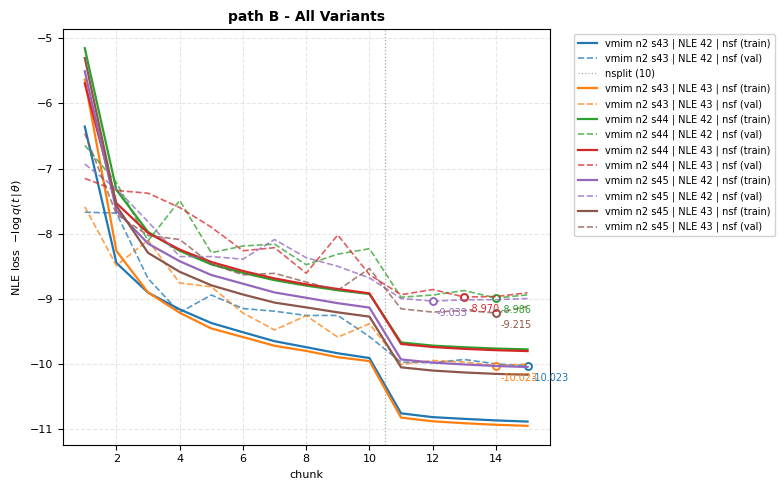

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import yaml

NLE_SEEDS = [42, 43]

def nle_loss(a, fam, nle_seed):
    """(chunks, train, val) from an arm's loss_history.npy, or None."""
    f = a["nle"] / a["scope"] / fam / f"seed_{nle_seed}" / "loss_history.npy"
    
    if not f.exists():
        return None
        
    h = np.load(f)
    if h.ndim == 1:
        h = h[None, :]
    return h[:, 0], h[:, 1], h[:, 2]

def nsplit_of(a):
    """nsplit drives the phase-1 -> phase-2 boundary."""
    return int((yaml.safe_load(open(a["cfg"])).get("nle") or {}).get("nsplit", 10))

for g, v in G.items():
    arms = list(v["arms"].items())
    
    # Create a single plot instead of a grid
    fig, ax = plt.subplots(figsize=(8, 5))
    any_data = False
    
    # Use a colormap to automatically assign different colors to each variant
    cmap = plt.get_cmap("tab10")
    color_idx = 0
    
    # Keep track of where we drew the nsplit line so we don't draw it multiple times
    ns_drawn = set()

    for k, a in arms:
        ns = nsplit_of(a)
        
        for fam in v["families"]:
            for nle_seed in NLE_SEEDS:
                d = nle_loss(a, fam, nle_seed)

                if d is None:
                    continue
                
                x, tr, va = d
                c = cmap(color_idx % 10)  # Cycle through 10 distinct colors
                
                # Create a clear label for the legend (e.g. "vmim n3 s43 | NLE 42 | nsf")
                variant_label = f"{k} | NLE {nle_seed} | {fam}"
                
                # Plot Train (solid) and Val (dashed)
                ax.plot(x, tr, "-", color=c, lw=1.6, label=f"{variant_label} (train)")
                ax.plot(x, va, "--", color=c, lw=1.2, alpha=0.75, label=f"{variant_label} (val)")
                
                # Mark the minimum validation loss
                b = int(np.argmin(va))
                ax.plot(x[b], va[b], "o", color=c, ms=5, mfc="white", mew=1.4)
                ax.annotate(f"{va[b]:.3f}", (x[b], va[b]), textcoords="offset points",
                            xytext=(3, -11), fontsize=7, color=c)
                
                any_data = True
                
                # Draw the split vertical line if appropriate
                if len(x) > ns and ns not in ns_drawn:
                    ax.axvline(ns + 0.5, color="grey", ls=":", lw=0.9, alpha=0.7, label=f"nsplit ({ns})")
                    ns_drawn.add(ns)
                    
                color_idx += 1

    ax.set_title(f"{g} - All Variants", fontsize=10, fontweight="semibold")
    ax.set_xlabel("chunk", fontsize=8)
    ax.set_ylabel("NLE loss  $-\\log q(t\\,|\\,\\theta)$", fontsize=8)
    ax.grid(True, ls="--", alpha=0.3)
    ax.tick_params(labelsize=8)
    
    if not any_data:
        ax.text(0.5, 0.5, "no loss_history yet", ha="center", va="center",
                transform=ax.transAxes, color="grey", fontsize=10)
    else:
        # Put the legend outside the plot on the right so it doesn't overlap the curves
        ax.legend(fontsize=7, framealpha=0.9, bbox_to_anchor=(1.04, 1), loc="upper left")

    fig.tight_layout()
    plt.show()

## 6. Seed ensembles

Every point is one `(compressor seed, NLE seed)` cell -- nothing is averaged
away. The question in every panel is whether the arm-to-arm gap clears the
seed-to-seed scatter, and a bar chart with an error bar hides exactly that.

Point `REPORTS` below at each stage-4 output directory. The dict **key** is the
group label used everywhere, and the dict **order** fixes both the plot order
and the reference arm (the first entry).

In [11]:
REPORTS = {
    "cnn vmim n1": "sbc_out/pathB/noise/vmim_n1",
    "cnn vmim n2": "sbc_out/pathB/noise/vmim_n2",
    "cnn vmim n3": "sbc_out/pathB/noise/vmim_n3",

    "cnn mse n1": "sbc_out/pathB/noise/mse_n1",
    "cnn mse n2": "sbc_out/pathB/noise/mse_n2",
    "cnn mse n3": "sbc_out/pathB/noise/mse_n3",
}


In [3]:
REPORTS = {
    "no jit no floor": "sbc_out/pathB/dequant/jit0_floor0",
    "no jit 1e-2 floor": "sbc_out/pathB/dequant/jit0_floor_p_01",
    "0p05 jit 1e-2 floor": "sbc_out/pathB/dequant/jit0p05_floor_p_01",
    "0p10 jit 1e-2 floor": "sbc_out/pathB/dequant/jit0p10_floor_p_01",

}

In [12]:
import glob, re
import pandas as pd
import matplotlib.pyplot as plt



PARAMS = ["$\\log_{10}(F_x)$", "$\\tau$", "$r_{H/S}$", "$\\log_{10}(M_{min})$"]
PSHORT = {PARAMS[0]: r"$\log_{10}F_x$", PARAMS[1]: r"$\tau$",
          PARAMS[2]: r"$r_{H/S}$",      PARAMS[3]: r"$\log_{10}M_{\min}$"}
TOL = np.sqrt(2 / 29)      # 1-sigma tolerance on the calibration ratio, B=30 bins


def load_reports(reports=REPORTS, mode="filtered_dlogp10", root=None):
    """Tidy frame: one row per (group, compressor seed, NLE seed)."""
    frames = []
    for label, p in reports.items():
        p = Path(p)
        if root is not None and not p.is_absolute():
            p = Path(root) / p
        f = p if p.suffix == ".csv" else p / "metrics.csv"
        if not f.exists():
            print(f"  [missing] {label:<20} {f}")
            continue
        d = pd.read_csv(f)
        d.columns = [c.strip() for c in d.columns]
        d = d[d["mode"] == mode].copy()
        d["group"] = label                       # the KEY, not a parsed string
        # make_sbc_list.py writes "<label> c<comp seed> n<nle seed>". Anchor to
        # the END: a bare \bn(\d+)\b would match the "n1" inside the label and
        # silently report the noise level as the NLE seed.
        s = d["arm"].str.extract(r"\bc(\d+)\s+n(\d+)\s*$")
        d["cs"], d["ns"] = s[0].astype("Int64"), s[1].astype("Int64")
        d["report"] = str(f.parent)
        frames.append(d)
    if not frames:
        raise FileNotFoundError("no metrics.csv found -- check REPORTS")
    return pd.concat(frames, ignore_index=True)


DF = load_reports(root=REPO)
ORDER = [g for g in REPORTS if g in set(DF["group"])]      # dict order = plot order
COL = dict(zip(ORDER, plt.get_cmap("tab10").colors))
MK = ["o", "s", "^", "D", "v", "P"]                        # one per compressor seed
REF = ORDER[0]

print(f"{len(DF)} arms from {len(ORDER)} reports   (reference = {REF!r})\n")
print(f"{'group':<20}{'n':>3}{'comp seeds':>16}{'nle seeds':>12}{'GV median':>12}"
      f"{'spread':>9}")
for g in ORDER:
    s = DF[DF["group"] == g]
    gv = s["GV_4x4"].values
    print(f"{g:<20}{len(s):>3}{str(sorted(s['cs'].dropna().unique())):>16}"
          f"{str(sorted(s['ns'].dropna().unique())):>12}{np.median(gv):12.3e}"
          f"{gv.max()/gv.min():8.2f}x")


36 arms from 6 reports   (reference = 'cnn vmim n1')

group                 n      comp seeds   nle seeds   GV median   spread
cnn vmim n1           6[np.int64(43), np.int64(44), np.int64(45)][np.int64(42), np.int64(43)]   5.967e-10    1.95x
cnn vmim n2           6[np.int64(43), np.int64(44), np.int64(45)][np.int64(42), np.int64(43)]   1.036e-09    2.24x
cnn vmim n3           6[np.int64(43), np.int64(44), np.int64(45)][np.int64(42), np.int64(43)]   1.244e-09    1.56x
cnn mse n1            6[np.int64(43), np.int64(44), np.int64(45)][np.int64(42), np.int64(43)]   2.039e-09    2.03x
cnn mse n2            6[np.int64(43), np.int64(44), np.int64(45)][np.int64(42), np.int64(43)]   4.087e-09    1.90x
cnn mse n3            6[np.int64(43), np.int64(44), np.int64(45)][np.int64(42), np.int64(43)]   8.150e-09   11.16x


### 6a. Posterior volume and marginal width

Two panels, one figure.

**Left -- GV.** $\det(\Sigma_{4\times4})^{1/2}$ is a *single* number per run, so
the arms go on x, log scale. Marker **shape** = compressor seed,
**filled/open** = NLE seed; shape-clustering versus fill-pairing shows which
stage carries the variance.

**Right -- $\sigma$.** Parameters on x, arms offset within each. Log scale
because the four parameters differ by an order of magnitude.

Read them together: if the marginals nearly coincide but GV does not, the
difference is in the **correlation structure**, not the widths.

In [13]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter, LogLocator, NullFormatter
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------------
# 1. Style presets
# ---------------------------------------------------------------------------
STYLE = "beamer"

PRESETS = {
    "beamer": dict(
        family="sans-serif", fonts=["DejaVu Sans", "Calibri"],
        fs_label=11, fs_tick=9, fs_legend=9, fs_title=11.0,
        lw_axes=1.0, lw_lines=2.0, ms_gv=9.0, ms_sig=5.0, nticks=4,
        fig_gv_w=3.2, fig_gv_h=3.5,     # <-- Reduced width from 4.0 to 3.2
        fig_sig_w=4.5, fig_sig_h=4.5,
    ),
    "paper": dict(
        family="serif", fonts=["DejaVu Serif", "Times New Roman"],
        fs_label=9, fs_tick=7.5, fs_legend=8, fs_title=9.5,
        lw_axes=0.8, lw_lines=1.5, ms_gv=4.5, ms_sig=3.5, nticks=5,
        fig_gv_w=2.5, fig_gv_h=3.0,     # <-- Reduced width from 3.3 to 2.5
        fig_sig_w=3.5, fig_sig_h=3.5,
    ),
}

def _rc(P):
    return {
        "font.family": P["family"],
        ("font.sans-serif" if P["family"] == "sans-serif" else "font.serif"): P["fonts"],
        "mathtext.fontset": "custom" if P["family"] == "sans-serif" else "dejavuserif",
        "font.size": P["fs_tick"],
        "axes.labelsize": P["fs_label"],
        "axes.titlesize": P["fs_title"],
        "xtick.labelsize": P["fs_tick"],
        "ytick.labelsize": P["fs_tick"],
        "legend.fontsize": P["fs_legend"],
        "axes.linewidth": P["lw_axes"],
        "xtick.direction": "in", "ytick.direction": "in",
        "xtick.top": True, "ytick.right": True,
        "legend.frameon": False,
        "lines.solid_capstyle": "round",
        "pdf.fonttype": 42, "ps.fonttype": 42,
    }

MARKERS = ["o", "s", "^", "D", "v", "<", ">"]
RNG = np.random.default_rng(42)
JITTER = 0.08

# ---------------------------------------------------------------------------
# 2. Helpers
# ---------------------------------------------------------------------------
def _log_candidates(lo, hi, mantissas):
    e0, e1 = int(np.floor(np.log10(lo))), int(np.ceil(np.log10(hi)))
    return [m * 10.0 ** e for e in range(e0, e1 + 1) for m in mantissas
            if lo <= m * 10.0 ** e <= hi]

def _thin(vals, n):
    if len(vals) <= n:
        return vals
    idx = np.unique(np.round(np.linspace(0, len(vals) - 1, n)).astype(int))
    return [vals[i] for i in idx]

def _fmt_pow10(v, _=None):
    e = int(np.round(np.log10(v)))
    m = v / 10.0 ** e
    return rf"$10^{{{e}}}$" if abs(m - 1) < 1e-6 else rf"${m:g}\times10^{{{e}}}$"

def _fmt_plain(v, _=None):
    return f"{float(f'{v:.3g}'):g}"

def set_log_yticks(ax, n, mode="nice", pin=1.0):
    lo, hi = ax.get_ylim()

    if mode == "decade":
        e_lo, e_hi = int(np.ceil(np.log10(lo))), int(np.floor(np.log10(hi)))
        while (e_hi - e_lo + 1) < n:
            down = lo / 10.0 ** (e_lo - 1)
            up = 10.0 ** (e_hi + 1) / hi
            if down <= up:
                lo, e_lo = 10.0 ** (e_lo - 1), e_lo - 1
            else:
                hi, e_hi = 10.0 ** (e_hi + 1), e_hi + 1
        exps = list(range(e_lo, e_hi + 1))
        ticks = _thin([10.0 ** e for e in exps], n)
        fmt = _fmt_pow10
    else:
        best, best_score = [pin], (10 ** 9, 10 ** 9, 10 ** 9)
        for rank, r in enumerate((2.0, 10.0, 4.0, 3.0, 1.5, 1.25)):
            k0 = int(np.ceil(np.log(lo / pin) / np.log(r)))
            k1 = int(np.floor(np.log(hi / pin) / np.log(r)))
            cand = [pin * r ** k for k in range(k0, k1 + 1)]
            if len(cand) < 2:
                continue
            ok = 3 <= len(cand) <= n + 1
            score = (0 if ok else 1, rank if ok else abs(len(cand) - n), rank)
            if score < best_score:
                best, best_score = cand, score
        ticks = _thin(best, n) if len(best) > n else best
        if pin not in ticks and lo <= pin <= hi:
            ticks = sorted(set(ticks + [pin]))
        fmt = _fmt_plain

    ax.yaxis.set_major_locator(FixedLocator(ticks))
    ax.yaxis.set_major_formatter(FuncFormatter(fmt))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=tuple(np.arange(2, 10)), numticks=200))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_ylim(lo, hi)

def style_axis(ax, lw_axes):
    ax.tick_params(which="both", top=True, right=True, direction="in")
    for s in ax.spines.values():
        s.set_linewidth(lw_axes)
        s.set_color("black")
        s.set_zorder(5)

def wrap_label(g, maxlen=9):
    g = str(g)
    words = g.split()
    if len(g) <= maxlen or len(words) == 1:
        return g
    return "\n".join(words[:3])

# ---------------------------------------------------------------------------
# 3. Plotting Functions
# ---------------------------------------------------------------------------

def plot_posterior_volume(DF, ORDER, COL, out="posterior_volume.pdf",
                          gv_col="GV_4x4", seed_col="cs", show_seed_legend=True, style=STYLE):
    P = PRESETS[style]
    
    with plt.rc_context(_rc(P)):
        fig, ax = plt.subplots(figsize=(P["fig_gv_w"], P["fig_gv_h"]))
        
        xt = np.arange(len(ORDER))
        xlabels = [wrap_label(g) for g in ORDER]

        if seed_col in DF.columns:
            seeds = sorted(s for s in DF[seed_col].dropna().unique())
        else:
            seeds = []
        mk = {s: MARKERS[i % len(MARKERS)] for i, s in enumerate(seeds)}

        for i, g in enumerate(ORDER):
            s = DF[DF["group"] == g]
            if s.empty: continue
            
            gv = s[gv_col].values
            med = np.median(gv)
            
            ax.hlines(med, i - 0.33, i + 0.33, color=COL[g], lw=P["lw_lines"],
                      alpha=0.55, zorder=2, capstyle="round")
                      
            if len(gv) > 1:
                ax.vlines(i, np.min(gv), np.max(gv), color=COL[g],
                          lw=P["lw_lines"] * 0.5, alpha=0.45, zorder=1)
                          
            if seed_col in s.columns and s[seed_col].notna().any():
                for c_seed, sub in s.groupby(seed_col):
                    v = sub[gv_col].values
                    ax.plot([i] * len(v), v, ls="none", marker=mk.get(c_seed, "o"),
                            ms=P["ms_gv"], color=COL[g], mfc=COL[g], mec="white",
                            mew=0.6, zorder=3)
            else:
                ax.plot([i] * len(gv), gv, ls="none", marker="o", ms=P["ms_gv"],
                        color=COL[g], mfc=COL[g], mec="white", mew=0.6, zorder=3)

        ax.set_yscale("log")
        ax.set_xlim(-0.6, len(ORDER) - 0.4)
        
        gv_all = DF[gv_col].values
        g_lo, g_hi = np.min(gv_all), np.max(gv_all)
        head = 2.0 if (show_seed_legend and seeds) else 1.25
        ax.set_ylim(g_lo / 1.6, g_hi * head)
        
        ax.set_xticks(xt)
        
        # --- NEW: Rotate labels 45 degrees and anchor to the right ---
        ax.set_xticklabels(xlabels, linespacing=0.95, rotation=45, ha="right", rotation_mode="anchor")
        
        ax.set_ylabel(r"GV = $\det(\Sigma_{4\times4})^{1/2}$", labelpad=1.5)
        ax.set_title("Posterior volume", pad=6)
        ax.grid(True, axis="y", ls=(0, (2, 2)), lw=0.5, alpha=0.45, zorder=0)
        
        set_log_yticks(ax, P["nticks"], mode="decade")
        style_axis(ax, P["lw_axes"])

        if show_seed_legend and seeds:
            handles = [Line2D([], [], ls="none", marker=mk[s], ms=P["ms_gv"] - 0.7,
                              color="0.35", mfc="0.35", mec="white", mew=0.5,
                              label=f"seed {int(s)}") for s in seeds]
            ax.legend(handles=handles, loc="upper center", ncol=len(seeds),
                      columnspacing=0.7, borderaxespad=0.25, handletextpad=0.25)

        fig.tight_layout()
        fig.savefig(out)
        fig.savefig(out.replace(".pdf", ".png"), dpi=600)
        plt.close(fig)

def plot_marginal_widths(DF, ORDER, COL, PARAMS, PSHORT, REF,
                         out="marginal_widths.pdf", style=STYLE):
    P = PRESETS[style]
    
    with plt.rc_context(_rc(P)):
        fig, axes = plt.subplots(2, 2, figsize=(P["fig_sig_w"], P["fig_sig_h"]), 
                                 sharex=True, sharey=True)
        axes = axes.flatten()
        
        xt = np.arange(len(ORDER))
        xlabels = [wrap_label(g) for g in ORDER]
        pcol = plt.rcParams["axes.prop_cycle"].by_key()["color"]
        
        lo_all, hi_all = np.inf, -np.inf

        for pi, p in enumerate(PARAMS):
            ax = axes[pi]
            c = pcol[pi % len(pcol)]
            ref_med = np.median(DF[DF["group"] == REF][f"sigma_{p}"].values)

            med, vmin, vmax = [], [], []
            for gi, g in enumerate(ORDER):
                v = DF[DF["group"] == g][f"sigma_{p}"].values / ref_med
                med.append(np.median(v)); vmin.append(v.min()); vmax.append(v.max())
                jit = RNG.uniform(-JITTER, JITTER, size=len(v))
                ax.plot(gi + jit, v, ls="none", marker="d", ms=P["ms_sig"], color=c,
                        alpha=0.75, mec="white", mew=0.4, zorder=3)
                        
            lo_all = min(lo_all, min(vmin)); hi_all = max(hi_all, max(vmax))

            ax.plot(xt, med, "-", color=c, lw=P["lw_lines"], zorder=4, solid_joinstyle="round")
            ax.fill_between(xt, vmin, vmax, color=c, alpha=0.16, lw=0, zorder=1)
            ax.axhline(1.0, color="0.15", ls=(0, (1, 1.6)), lw=0.9, zorder=2)

            ax.set_yscale("log")
            ax.grid(True, axis="y", ls=(0, (2, 2)), lw=0.5, alpha=0.45, zorder=0)
            ax.text(0.035, 0.94, PSHORT[p], transform=ax.transAxes,
                    ha="left", va="top",
                    bbox=dict(fc="white", ec="0.75", lw=0.5, pad=1.3, boxstyle="round,pad=0.18"), 
                    zorder=6)
                    
            style_axis(ax, P["lw_axes"])
            ax.set_xticks(xt)

        # Set shared limits and ticks
        pad = (hi_all / lo_all) ** 0.05
        axes[0].set_ylim(lo_all / pad, hi_all * pad ** 3.0)
        axes[0].set_xlim(-0.6, len(ORDER) - 0.4)
        
        set_log_yticks(axes[0], P["nticks"], mode="nice")

        for pi, ax in enumerate(axes):
            if pi >= 2:
                ax.set_xticklabels(xlabels, linespacing=0.95)

        fig.supylabel(r"relative marginal width  $\sigma/\sigma_{\mathrm{ref}}$", fontsize=P["fs_label"])
        fig.suptitle(f"Marginal widths (relative to {REF})", fontsize=P["fs_title"])
        
        fig.tight_layout()
        fig.savefig(out)
        fig.savefig(out.replace(".pdf", ".png"), dpi=600)
        plt.close(fig)

### 6b. Calibration

`calibnsig` $=(\hat\chi^2-1)/\sqrt{2/(B-1)}$ is already in units of the
expected fluctuation, so 0 is perfect and the shaded bands are $\pm1$ and
$\pm2$. Only positive deviations are failures: $\hat\chi^2<1$ is a rank
histogram flatter than chance.

Calibration is **far noisier than width** -- in this pipeline the identical
configuration re-run has moved `calibnsig`($\tau$) by $\sim4$ while $\sigma$
moved by 1%. The printed `seed spread` is the within-configuration range: if it
is comparable to the gap between configurations, the difference is not
resolved.

In [14]:
def plot_calibration_ratio(DF, ORDER, COL, PARAMS, PSHORT,
                           out="calibration_ratio.pdf", style=STYLE):
    """
    Plots the SBC calibration ratio (\hat{\chi}^2) in a 2x2 grid.
    Converts 'calibnsig' -> chi^2 on the fly using TOLERANCE.
    """
    P = PRESETS[style]
    TOL = np.sqrt(2 / 29)  # 1-sigma tolerance for B=30 bins
    
    with plt.rc_context(_rc(P)):
        fig, axes = plt.subplots(2, 2, figsize=(P["fig_sig_w"], P["fig_sig_h"]), 
                                 sharex=True, sharey=True)
        axes = axes.flatten()
        
        xt = np.arange(len(ORDER))
        xlabels = [wrap_label(g) for g in ORDER]
        pcol = plt.rcParams["axes.prop_cycle"].by_key()["color"]
        
        # Colors for the thresholds
        c_safe = "#009E73"  # Soft green
        c_perf = "0.15"     # Near black
        c_marg = "#D55E00"  # Orange/Red
        
        lo_all, hi_all = 0.0, 1.5  # Base limits, will expand if data exceeds

        for pi, p in enumerate(PARAMS):
            ax = axes[pi]
            c = pcol[pi % len(pcol)]
            
            # 1. Background shading & target lines
            ax.axhspan(0, 1.0 + TOL, color=c_safe, alpha=0.12, zorder=0)
            ax.axhline(1.0, color=c_perf, lw=P["lw_lines"]*0.8, zorder=1)
            ax.axhline(1.0 + TOL, color=c_marg, ls="--", lw=P["lw_lines"]*0.8, zorder=1)

            med, vmin, vmax = [], [], []
            for gi, g in enumerate(ORDER):
                # Convert calibnsig back to the \hat{\chi}^2 scale
                v_calib = DF[DF["group"] == g][f"calibnsig_{p}"].values
                v = v_calib * TOL + 1.0
                
                med.append(np.median(v))
                vmin.append(v.min())
                vmax.append(v.max())
                
                # Scatter seeds with jitter
                jit = RNG.uniform(-JITTER, JITTER, size=len(v))
                ax.plot(gi + jit, v, ls="none", marker="o", ms=P["ms_sig"]*1.2, color=c,
                        alpha=0.75, mec="white", mew=0.4, zorder=3)
                        
            hi_all = max(hi_all, max(vmax))

            # Trend line and variance shading
            ax.plot(xt, med, "-", color=c, lw=P["lw_lines"], zorder=4, solid_joinstyle="round")
            ax.fill_between(xt, vmin, vmax, color=c, alpha=0.16, lw=0, zorder=2)

            # Parameter Label Box (Consistent with marginal widths)
            ax.text(0.035, 0.94, PSHORT[p], transform=ax.transAxes,
                    ha="left", va="top",
                    bbox=dict(fc="white", ec="0.75", lw=0.5, pad=1.3, boxstyle="round,pad=0.18"), 
                    zorder=6)
                    
            # Grid and styling
            ax.grid(True, axis="y", ls=(0, (2, 2)), lw=0.5, alpha=0.45, zorder=0)
            style_axis(ax, P["lw_axes"])
            ax.set_xticks(xt)

        # Set shared limits and ticks
        axes[0].set_ylim(0, hi_all * 1.1)
        axes[0].set_xlim(-0.6, len(ORDER) - 0.4)
        
        # Linear locator for chi^2
        from matplotlib.ticker import MaxNLocator
        axes[0].yaxis.set_major_locator(MaxNLocator(nbins=P["nticks"], prune='lower'))

        for pi, ax in enumerate(axes):
            if pi >= 2:
                # Rotate labels and anchor to the right
                ax.set_xticklabels(xlabels, linespacing=0.95, rotation=45, ha="right", rotation_mode="anchor")

        # Global labels and titles
        fig.supylabel(r"SBC Ratio ($\hat{\chi}^2$)", fontsize=P["fs_label"])
        fig.suptitle(r"Calibration Ratio ($\hat{\chi}^2 \leq 1.26$ is perfectly consistent)", fontsize=P["fs_title"])
        
        # Unified Legend for Thresholds
        import matplotlib.patches as mpatches
        legend_elements = [
            Line2D([0], [0], color=c_perf, lw=P["lw_lines"], label="Perfect (1.0)"),
            Line2D([0], [0], color=c_marg, lw=P["lw_lines"], ls="--", label="Upper Margin (1.26)"),
            mpatches.Patch(color=c_safe, alpha=0.15, label="Statistically Consistent Zone")
        ]
        
        fig.legend(handles=legend_elements, loc='lower center', ncol=3, 
                   frameon=False, bbox_to_anchor=(0.5, -0.02), fontsize=P["fs_legend"])

        fig.tight_layout()
        # Adjust bottom margin to prevent x-labels/legend from being clipped
        fig.subplots_adjust(bottom=0.22)
        
        fig.savefig(out)
        fig.savefig(out.replace(".pdf", ".png"), dpi=600)
        plt.close(fig)


def print_calibration_summary(DF, ORDER, PARAMS):
    """
    Prints a terminal summary table of the calibration metrics converted to \hat{\chi}^2.
    """
    TOL = np.sqrt(2 / 29)
    print(f"\n{'-'*80}")
    print(f"{'-'*80}")
    
    for g in ORDER:
        s = DF[DF["group"] == g]
        if s.empty: continue
        
        # Convert all columns to chi^2 for the printout
        v_chi2_dict = {p: s[f"calibnsig_{p}"].values * TOL + 1.0 for p in PARAMS}
        allv = np.concatenate(list(v_chi2_dict.values()))
        
        med = [np.median(v_chi2_dict[p]) for p in PARAMS]
        spr = [np.max(v_chi2_dict[p]) - np.min(v_chi2_dict[p]) for p in PARAMS]
        
        # RMS deviation from perfect calibration (1.0)
        rms = np.sqrt(((allv - 1.0)**2).mean())
        
        # Format the arrays as strings for clean printing
        med_str = "[" + ", ".join(f"{m:4.2f}" for m in med) + "]"
        spr_str = "[" + ", ".join(f"{s:4.2f}" for s in spr) + "]"
        
        print(f"{g:<22}{rms:15.2f}{allv.max():9.2f}   {med_str}  |  {spr_str}")

    print(f"{'-'*80}")
    print("Spread is max-min WITHIN a configuration.\n")

# ============================================================================
# 4. Execution Block
# ============================================================================
if __name__ == "__main__":
    # The script now uses the DF, ORDER, COL, PARAMS, PSHORT, and REF 
    # dynamically generated via load_reports() at the top of the file.
    
    # Optional: Generate Paper style
    # plot_posterior_volume(DF, ORDER, COL, out="posterior_volume_paper.pdf", style="paper")
    # plot_marginal_widths(DF, ORDER, COL, PARAMS, PSHORT, REF, out="marginal_widths_paper.pdf", style="paper")
    # plot_calibration_ratio(DF, ORDER, COL, PARAMS, PSHORT, out="calibration_ratio_paper.pdf", style="paper")
    
    # Generate Beamer style
    plot_posterior_volume(DF, ORDER, COL, out="sbc_out/_img/posterior_volume_noise.pdf", style="beamer")
    plot_marginal_widths(DF, ORDER, COL, PARAMS, PSHORT, REF, out="sbc_out/_img/marginal_widths_noise.pdf", style="beamer")
    plot_calibration_ratio(DF, ORDER, COL, PARAMS, PSHORT, out="sbc_out/_img/calibration_ratio_noise.pdf", style="beamer")
    
    # Terminal summary for SBC Ratio
    print_calibration_summary(DF, ORDER, PARAMS)
    
    print("Figures generated successfully.")


--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
cnn vmim n1                      0.32     1.79   [1.20, 1.16, 1.05, 1.15]  |  [0.84, 1.10, 0.57, 0.65]
cnn vmim n2                      0.75     3.47   [1.14, 1.66, 1.18, 1.25]  |  [0.81, 2.65, 0.90, 1.51]
cnn vmim n3                      0.55     2.28   [1.48, 1.37, 1.31, 1.53]  |  [1.04, 0.99, 0.47, 0.89]
cnn mse n1                       0.66     2.42   [1.60, 1.37, 1.86, 1.16]  |  [1.26, 0.99, 0.96, 0.52]
cnn mse n2                       0.61     3.17   [1.41, 1.53, 1.22, 1.20]  |  [2.17, 0.79, 0.56, 0.81]
cnn mse n3                       0.78     2.81   [1.41, 1.58, 1.62, 1.26]  |  [0.92, 1.70, 0.84, 2.09]
--------------------------------------------------------------------------------
Spread is max-min WITHIN a configuration.

Figures generated successfully.
